# Convert data

In [1]:
!pip -q install GEOparse pandas numpy matplotlib


In [14]:
import GEOparse
import pandas as pd

gds = GEOparse.get_GEO(
    filepath="ignore_dir/GDS3257_full.soft",
    destdir="."
)
expression_df = gds.table

27-Dec-2025 22:21:30 INFO GEOparse - Parsing ignore_dir/GDS3257_full.soft: 
27-Dec-2025 22:21:30 DEBUG GEOparse - DATABASE: Geo
27-Dec-2025 22:21:30 DEBUG GEOparse - DATASET: GDS3257
27-Dec-2025 22:21:30 DEBUG GEOparse - SUBSET: GDS3257_1
27-Dec-2025 22:21:30 DEBUG GEOparse - SUBSET: GDS3257_2
27-Dec-2025 22:21:30 DEBUG GEOparse - SUBSET: GDS3257_3
27-Dec-2025 22:21:30 DEBUG GEOparse - SUBSET: GDS3257_4
27-Dec-2025 22:21:30 DEBUG GEOparse - SUBSET: GDS3257_5
27-Dec-2025 22:21:30 DEBUG GEOparse - SUBSET: GDS3257_6
27-Dec-2025 22:21:30 DEBUG GEOparse - SUBSET: GDS3257_7
27-Dec-2025 22:21:30 DEBUG GEOparse - SUBSET: GDS3257_8
27-Dec-2025 22:21:30 DEBUG GEOparse - SUBSET: GDS3257_9
27-Dec-2025 22:21:30 DEBUG GEOparse - SUBSET: GDS3257_10
27-Dec-2025 22:21:30 DEBUG GEOparse - SUBSET: GDS3257_11
27-Dec-2025 22:21:30 DEBUG GEOparse - SUBSET: GDS3257_12
27-Dec-2025 22:21:30 DEBUG GEOparse - SUBSET: GDS3257_13
27-Dec-2025 22:21:30 DEBUG GEOparse - ANNOTATION: 
27-Dec-2025 22:21:30 ERROR GEOpars

In [4]:
print(expression_df.head())
print(expression_df.columns)


         ID_REF    IDENTIFIER  GSM1684096  GSM1684098  GSM1684100  GSM1684102  \
0  ILMN_1343048  ILMN_1343048         NaN         NaN         NaN         NaN   
1  ILMN_1343049  ILMN_1343049         NaN         NaN         NaN         NaN   
2  ILMN_1343050  ILMN_1343050         NaN         NaN         NaN         NaN   
3  ILMN_1343052  ILMN_1343052         NaN         NaN         NaN         NaN   
4  ILMN_1343059  ILMN_1343059         NaN         NaN         NaN         NaN   

   GSM1684104  GSM1684095  GSM1684097  GSM1684099  ...  Platform_SPOTID  \
0         NaN         NaN         NaN         NaN  ...              NaN   
1         NaN         NaN         NaN         NaN  ...              NaN   
2         NaN         NaN         NaN         NaN  ...              NaN   
3         NaN         NaN         NaN         NaN  ...              NaN   
4         NaN         NaN         NaN         NaN  ...              NaN   

   Chromosome location Chromosome annotation GO:Function GO:Pr

In [15]:
expression_df.to_csv("ignore_dir/GDS3257_full.csv", index=False)


In [8]:
import pandas as pd

# 1. Load the dataset
# Replace 'your_data.csv' with the actual path to your file
df = pd.read_csv('ignore_dir/GDS3257_full.csv', low_memory=False)

# 2. Identify the columns
# Based on your description:
# - ID_REF is the unique feature ID
# - GSM... columns are the samples
# - Gene title, Gene symbol, etc., are annotation metadata

# We set the ID_REF as the index so that it becomes the column headers after rotation
df.set_index('ID_REF', inplace=True)

# 3. Filter for numeric sample columns only (Optional but recommended)
# This separates the expression data from the descriptive text (Gene symbol, etc.)
# sample_cols = [col for col in df.columns if col.startswith('GSM')]
# df_samples = df[sample_cols]

# 4. Rotate (Transpose) the data
# Now rows = Samples (GSM...), columns = Features (ID_REF)
df_transposed = df.transpose()

# 5. Save the file for the next step
df_transposed.to_csv('transposed_GDS3257.csv')

print("Transposition complete. File saved as 'transposed_GDS3257.csv'.")
print(f"New Shape: {df_transposed.shape}") # Should be (Number of Samples, ~20000)

Transposition complete. File saved as 'transposed_GDS3257.csv'.
New Shape: (128, 22283)


# Apply Outlier

In [107]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# 1. Load data
df = pd.read_csv('ignore_dir/transposed_GDS3257_add_target.csv', index_col=0)
df.dropna(axis=1, inplace=True)
X = df.drop(columns=['target'])
y = df['target'].map({'tumor': 1, 'normal': 0})


# 2. Split Data
X_train_full, X_test_full, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# 3. Row Outlier Removal
X_train_full = X_train_full.loc[:, X_train_full.var() > X_train_full.var().quantile(0.25)]
iso = IsolationForest(contamination=0.05, random_state=42) 
outlier_preds = iso.fit_predict(X_train_full)
X_train_cleaned = X_train_full[outlier_preds == 1]
y_train_cleaned = y_train_full[outlier_preds == 1]

print(f"Original train Shape: {X_train_full.shape}")
print(f"Remove outlier train Shape: {X_train_cleaned.shape}")

# 4. Feature Quality Filtering (CV Quantile)
cv_scores = X_train_cleaned.std() / (X_train_cleaned.mean())
cv_threshold = cv_scores.quantile(0.95)
reliable_features = cv_scores[cv_scores < cv_threshold].index
X_train_reliable = X_train_cleaned[reliable_features]

print(f"After apply signal to noise ratio: {X_train_reliable.shape}")

# 5. Feature Selection (Top 400)
train_variances = X_train_reliable.var().sort_values(ascending=False)
top_400_features = train_variances.head(5).index

X_train_final = X_train_reliable[top_400_features]
X_test_final = X_test_full[top_400_features]

# 6. Train & Compare Linear Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVC (Linear Kernel)": SVC(kernel='linear', random_state=42),
    "Perceptron (Single Node)": Perceptron(max_iter=1000, random_state=42)
}

print(f"Final features selected: {X_train_final.shape[1]}")
print("-" * 30)

for name, model in models.items():
    # ทุกโมเดลในกลุ่มนี้ใช้ข้อมูล Scaled
    model.fit(X_train_final, y_train_cleaned)
    y_pred = model.predict(X_test_final)
    
    print(f"\nModel: {name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

Original train Shape: (85, 16712)
Remove outlier train Shape: (80, 16712)
After apply signal to noise ratio: (80, 15876)
Final features selected: 5
------------------------------

Model: Logistic Regression
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        12

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22


Model: SVC (Linear Kernel)
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        12

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22


Model: Perceptron (Single Node)
Accuracy: 0.8182
              precision    

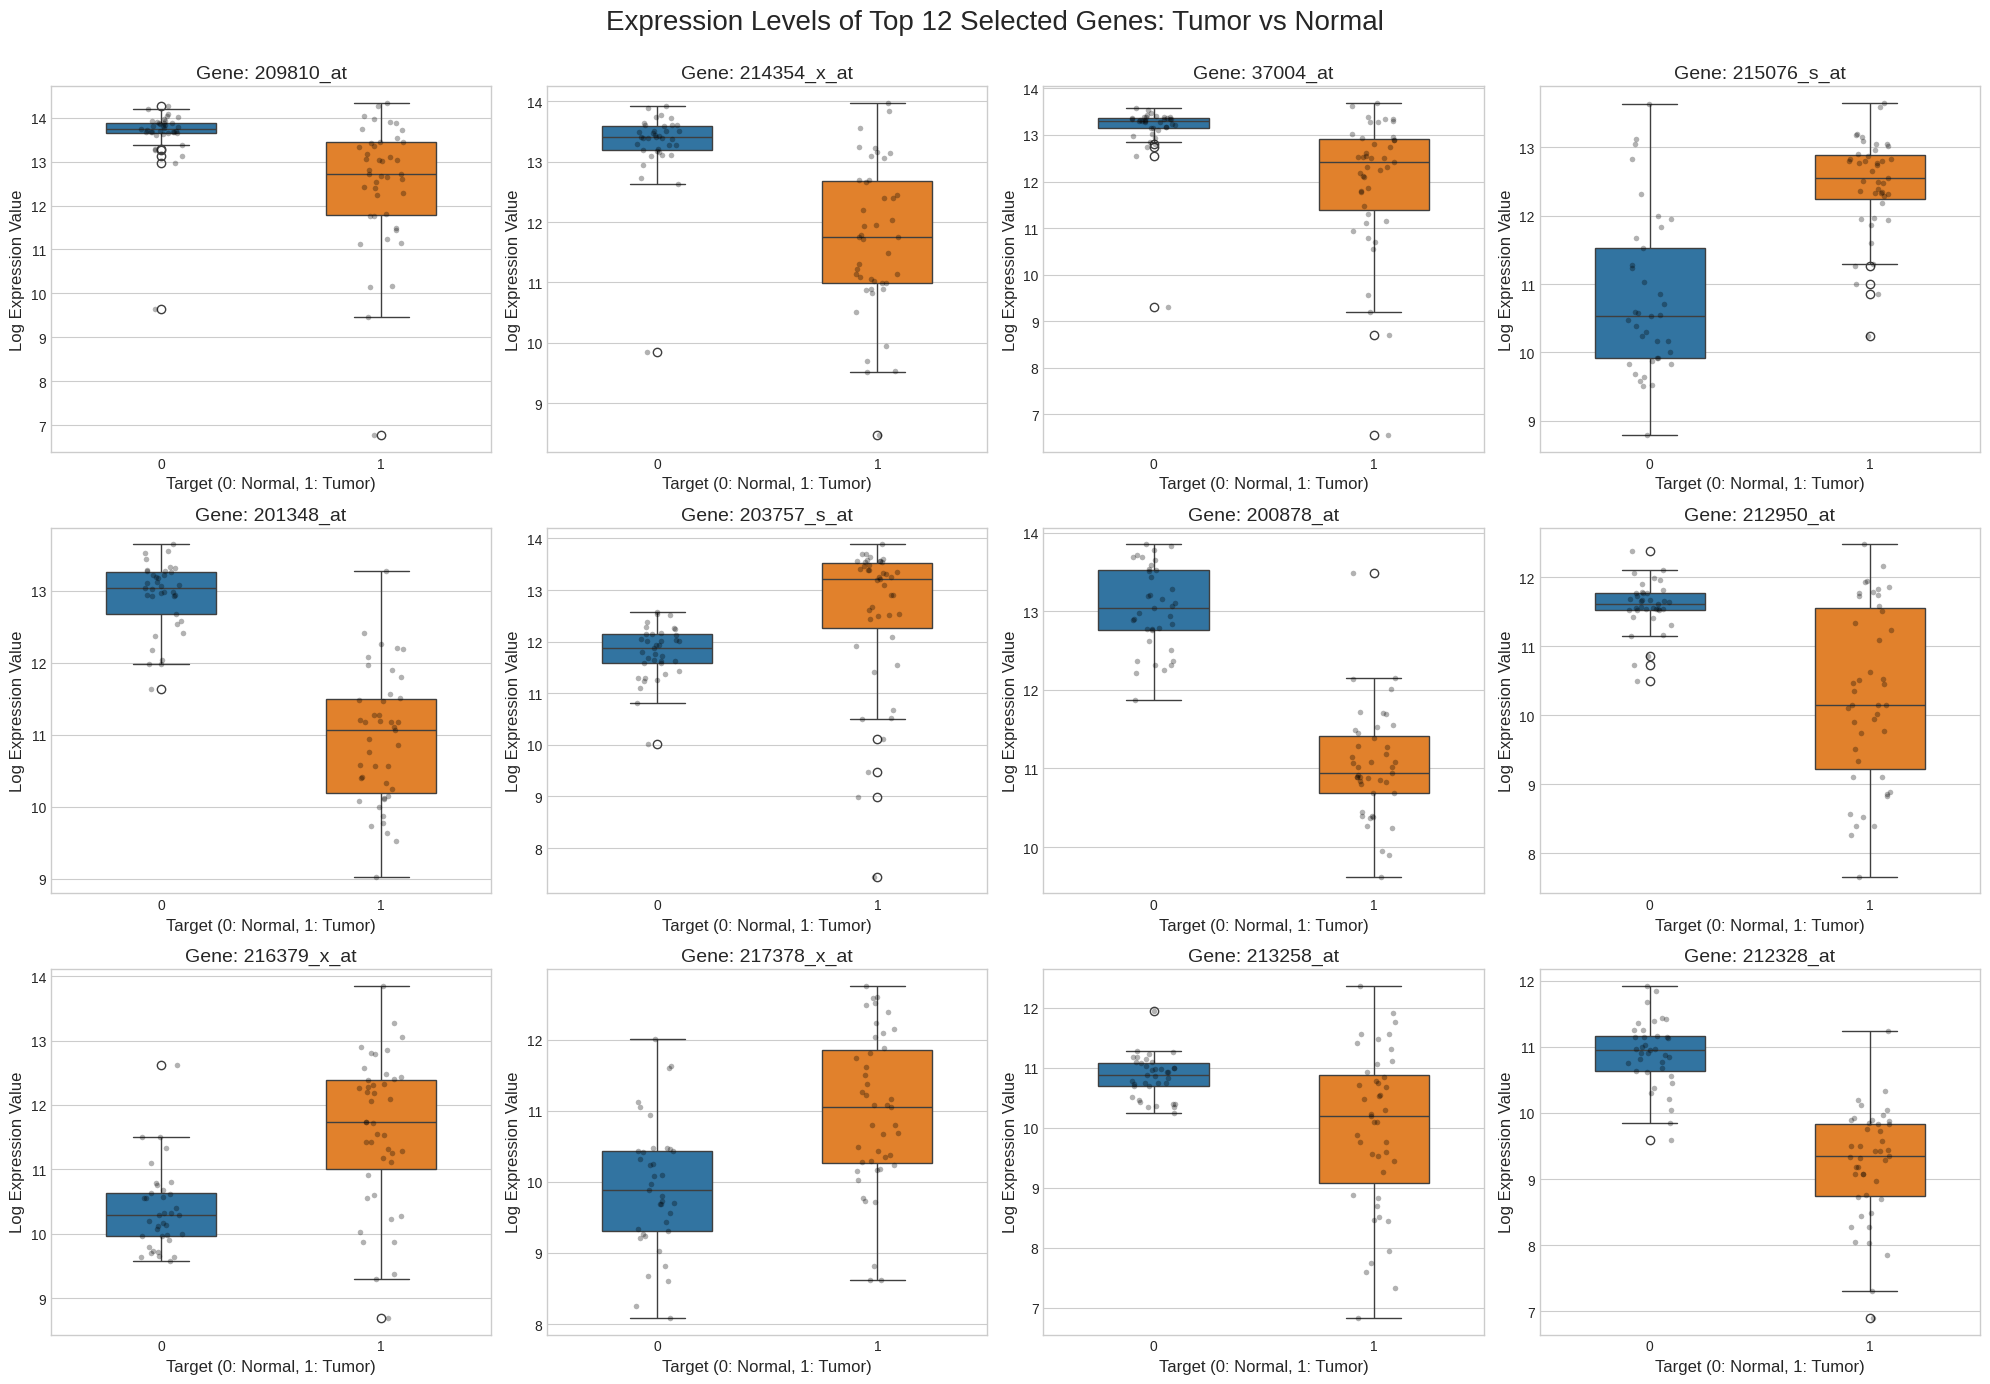

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าสไตล์ของกราฟ
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
fig.suptitle('Expression Levels of Top 12 Selected Genes: Tumor vs Normal', fontsize=20, y=0.95)

# รายชื่อยีน 12 ตัวที่เราเลือกไว้
genes_to_plot = top_400_features # ในโค้ดคุณคือ .head(12)

# วนลูปสร้าง Boxplot สำหรับแต่ละยีน
for i, gene in enumerate(genes_to_plot):
    row = i // 4
    col = i % 4
    
    # สร้าง Boxplot พร้อมแต้มข้อมูลจริง (Stripplot) เพื่อให้เห็นการกระจายตัว
    sns.boxplot(x=y_train_cleaned, y=X_train_final[gene], ax=axes[row, col], hue=y_train_cleaned, legend=False, width=0.5) 
    sns.stripplot(x=y_train_cleaned, y=X_train_final[gene], ax=axes[row, col], color='black', alpha=0.3, size=4)
    
    axes[row, col].set_title(f'Gene: {gene}', fontsize=14)
    axes[row, col].set_xlabel('Target (0: Normal, 1: Tumor)', fontsize=12)
    axes[row, col].set_ylabel('Log Expression Value', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

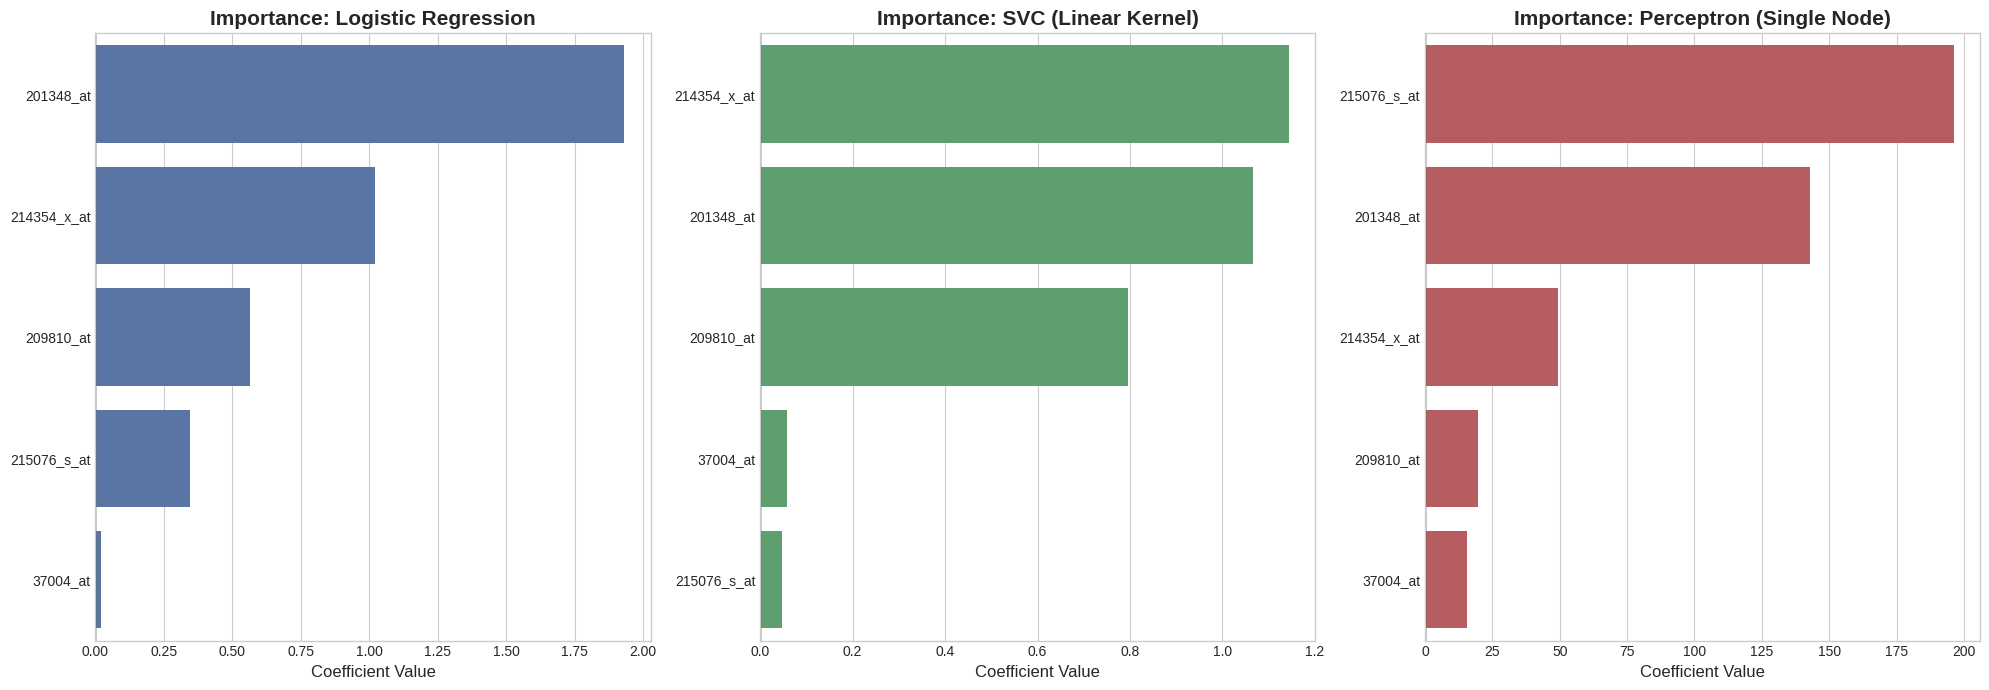

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. เตรียมข้อมูล Importance (อิงจากโมเดลที่ถูก Train แล้วในขั้นตอนก่อนหน้า)
# ตรวจสอบว่าได้ทำ Scaling ข้อมูลก่อน Train หรือไม่ เพื่อให้ค่า Importance เปรียบเทียบกันได้ภายในโมเดล
models_to_plot = {
    "Logistic Regression": models["Logistic Regression"],
    "SVC (Linear Kernel)": models["SVC (Linear Kernel)"],
    "Perceptron (Single Node)": models["Perceptron (Single Node)"]
}

# 2. สร้าง Subplots 1 แถว 3 คอลัมน์
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors = ['#4C72B0', '#55A868', '#C44E52'] # สีแยกแต่ละโมเดล

for i, (name, model) in enumerate(models_to_plot.items()):
    # ดึงค่า Coefficients
    coef_values = abs(model.coef_[0])
    features = top_400_features # รายชื่อยีน 12 ตัว
    
    # สร้าง DataFrame เฉพาะของโมเดลนั้นๆ และเรียงลำดับจากมากไปน้อย
    df_temp = pd.DataFrame({'Gene': features, 'Importance': coef_values})
    df_temp = df_temp.sort_values(by='Importance', ascending=False) # เรียงให้บวกอยู่บน
    
    # พล็อตกราฟแท่งแนวนอน
    sns.barplot(
        x='Importance', 
        y='Gene', 
        data=df_temp, 
        ax=axes[i], 
        color=colors[i]
    )
    
    # ตกแต่งกราฟ
    axes[i].set_title(f'Importance: {name}', fontsize=15, fontweight='bold')
    axes[i].axvline(x=0, color='black', linestyle='-', linewidth=1) # เส้นกลางที่ 0
    axes[i].set_xlabel('Coefficient Value', fontsize=12)
    axes[i].set_ylabel('') # ลบชื่อแกน Y ออกในรูปที่ 2 และ 3 เพื่อความสวยงาม
    # if i > 0:
    #     axes[i].set_yticklabels([]) # ซ่อนชื่อยีนในกราฟที่ 2 และ 3 เพราะเหมือนกัน

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load data
df = pd.read_csv('ignore_dir/transposed_GDS3257_add_target.csv', index_col=0)
df.dropna(axis=1, inplace=True)
X = df.drop(columns=['target'])
y = df['target'].map({'tumor': 1, 'normal': 0})

# 2. Split Data ก่อนทำอะไรทั้งสิ้น (เพื่อป้องกัน Data Leakage)
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. คำนวณความแปรปรวน (Variance) เฉพาะใน X_train_full เท่านั้น
train_variances = X_train_full.var().sort_values(ascending=False)

# เลือก 400 Features ที่ดีที่สุดจากชุดฝึก
top_400_features = train_variances.head(200).index

# กรองให้เหลือแค่ 400 Features ทั้งชุดฝึกและชุดทดสอบ
X_train = X_train_full[top_400_features]
X_test = X_test_full[top_400_features]

print(f"Original features: {X.shape[1]}")
print(f"Selected features based on Training Set: {X_train.shape[1]}")

# 4. Train Model ด้วยชุดข้อมูลที่กรองแล้ว
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Evaluate
y_pred = model.predict(X_test)

print("\n--- Model Results (No Data Leakage) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Original features: 22283
Selected features based on Training Set: 200

--- Model Results (No Data Leakage) ---
Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        12

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22



# Train 3 models

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# 1. Load data
df = pd.read_csv('ignore_dir/transposed_GDS3257_add_target.csv', index_col=0)
df.dropna(axis=1, inplace=True)
X = df.drop(columns=['target'])
y = df['target'].map({'tumor': 1, 'normal': 0})

# 2. Split Data ก่อนทำอะไรทั้งสิ้น (เพื่อป้องกัน Data Leakage)
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. คำนวณความแปรปรวน (Variance) เฉพาะใน X_train_full เท่านั้น
train_variances = X_train_full.var().sort_values(ascending=False)

# เลือก 200 Features ที่ดีที่สุดจากชุดฝึก
top_200_features = train_variances.head(200).index

# กรองให้เหลือแค่ 200 Features ทั้งชุดฝึกและชุดทดสอบ
X_train = X_train_full[top_200_features]
X_test = X_test_full[top_200_features]

# 4. Define the 3 models
models = {
    "SVM": SVC(kernel='linear', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# 5. Train, Predict, and Report
results = {}

print(f"Original features: {X.shape[1]}")
print(f"Selected features: {top_200_features.shape}\n")

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"================ {name} ================")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("\n")

# Summary Table
print("--- Final Comparison ---")
summary_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
print(summary_df.sort_values(by='Accuracy', ascending=False))

Original features: 22283
Selected features: (200,)

================ SVM ================
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        12

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22



================ Random Forest ================
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        12

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22





/home/oil/anaconda3/envs/ai-workshop/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [11:13:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


================ XGBoost ================
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        12

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22



--- Final Comparison ---
           Model  Accuracy
0            SVM       1.0
1  Random Forest       1.0
2        XGBoost       1.0


# Plot feature important

/tmp/ipykernel_136264/1396526435.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=svm_series.values, y=svm_series.index, ax=axes[0], palette="viridis")
/tmp/ipykernel_136264/1396526435.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_series.values, y=rf_series.index, ax=axes[1], palette="magma")
/tmp/ipykernel_136264/1396526435.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_series.values, y=xgb_series.index, ax=axes[2], palette="rocket")


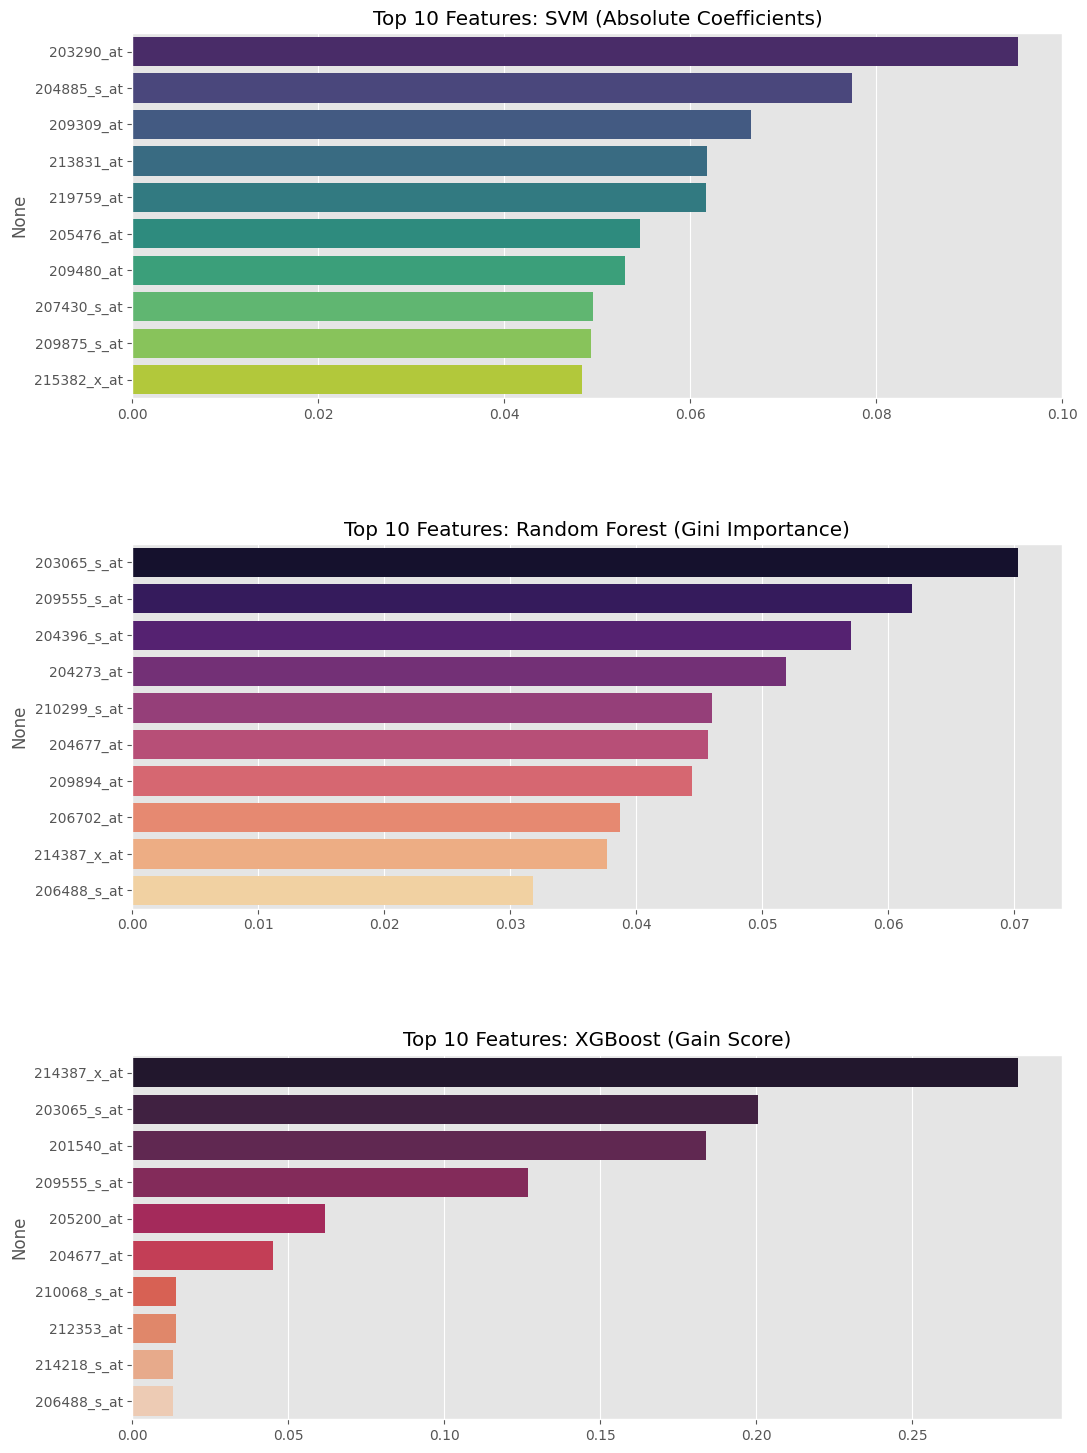

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าการแสดงผล
plt.style.use('ggplot')
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
plt.subplots_adjust(hspace=0.4)

# 1. SVM Importance (จาก Coefficients)
# เนื่องจากเราใช้ Linear Kernel จึงดึงค่า coef_ มาใช้ได้
num_top_feature = 10
svm_importance = np.abs(models["SVM"].coef_[0])
svm_series = pd.Series(svm_importance, index=top_200_features).sort_values(ascending=False).head(num_top_feature)
sns.barplot(x=svm_series.values, y=svm_series.index, ax=axes[0], palette="viridis")
axes[0].set_title(f"Top {num_top_feature} Features: SVM (Absolute Coefficients)")

# 2. Random Forest Importance
rf_importance = models["Random Forest"].feature_importances_
rf_series = pd.Series(rf_importance, index=top_200_features).sort_values(ascending=False).head(num_top_feature)
sns.barplot(x=rf_series.values, y=rf_series.index, ax=axes[1], palette="magma")
axes[1].set_title(f"Top {num_top_feature} Features: Random Forest (Gini Importance)")

# 3. XGBoost Importance
xgb_importance = models["XGBoost"].feature_importances_
xgb_series = pd.Series(xgb_importance, index=top_200_features).sort_values(ascending=False).head(num_top_feature)
sns.barplot(x=xgb_series.values, y=xgb_series.index, ax=axes[2], palette="rocket")
axes[2].set_title(f"Top {num_top_feature} Features: XGBoost (Gain Score)")

plt.show()